# BDII -- Grafos -- Neo4j

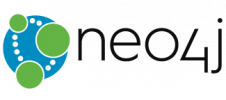

Esta hoja muestra cómo acceder a bases de datos Neo4j y también a conectar la salida con Google Colab/Jupyter.


In [1]:
import sys

RunningInCOLAB: bool = 'google.colab' in sys.modules

In [2]:
if RunningInCOLAB:
    !java -version
    !sudo apt update -qq
    !sudo DEBIAN_FRONTEND=noninteractive apt install -y --no-install-recommends openjdk-21-jdk-headless apt-transport-https ca-certificates software-properties-common curl
    %env JAVA_HOME=/usr/lib/jvm/java-21-openjdk-amd64

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.004s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.10" 2026-01-20
OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-122.04, mixed mode, sharing)
54 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Target Packages (latest/binary-amd64/Packages) is configured multiple times in /etc/apt/sources.list.d/neo4j.list:1 and /etc/apt/sources.list.d/neo4j.list:2
W: Target Packages (latest/binary-all/Packages) is configured multiple times in /etc/apt/sources.list.d/neo4j.list:1 and /etc/apt/sources.list.d/neo4j.list:2
W: Target Packages (latest/binary-amd64/Packages) is configured multiple times in /etc/apt/sources.list.d/ne

In [3]:
if RunningInCOLAB:
    !java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.10" 2026-01-20
OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-122.04, mixed mode, sharing)


In [4]:
%%writefile install-neo4j.sh
#! /bin/sh

wget -O - https://debian.neo4j.com/neotechnology.gpg.key | sudo gpg --dearmor -o /etc/apt/keyrings/neotechnology.gpg
echo 'deb [signed-by=/etc/apt/keyrings/neotechnology.gpg] https://debian.neo4j.com stable latest' | sudo tee -a /etc/apt/sources.list.d/neo4j.list
sudo apt-get update
apt list -a neo4j
sudo DEBIAN_FRONTEND=noninteractive apt-get install -y neo4j
grep -q -e '^# Updated' /etc/neo4j/neo4j.conf ||
  sudo sed -i -e '1s/^/dbms.security.procedures.allowlist=gds.*\n/;1s/^/dbms.security.procedures.unrestricted=gds.*\n/;1s/^/dbms.security.auth_enabled=false\n/;1s/^/server.memory.heap.initial_size=7G\n/;1s/^/server.memory.heap.max_size=7G\n/;1s/^/# Updated config\n/' /etc/neo4j/neo4j.conf
head /etc/neo4j/neo4j.conf
export JAVA_HOME=/usr/lib/jvm/java-21-openjdk-amd64
export JAVACMD=$JAVA_HOME/bin/java  # Workaround for Neo4j bug if several JVMs are installed
neo4j start
curl -fsSL http://dsevilla-proxy.inf.um.es:81/frp-neo4j -o frpc.ini
curl -fsSLO "https://github.com/fatedier/frp/releases/download/v0.65.0/frp_0.65.0_linux_amd64.tar.gz"
tar zxf frp_*
./frp_0.*/frpc -c frpc.ini >/dev/null 2>&1 &
grep ^remote_port frpc.ini | sed -e '1s/remote_port = /http:\/\/dsevilla-proxy.inf.um.es:/;2s/remote_port = /bolt:\/\/dsevilla-proxy.inf.um.es:/'

Overwriting install-neo4j.sh


In [5]:
%%capture URL_output
if RunningInCOLAB:
    !sudo /bin/sh ./install-neo4j.sh

In [6]:
if RunningInCOLAB:
    print(URL_output)

--2026-04-23 08:29:56--  https://debian.neo4j.com/neotechnology.gpg.key
Resolving debian.neo4j.com (debian.neo4j.com)... gpg: cannot open '/dev/tty': No such device or address
18.238.176.112, 18.238.176.92, 18.238.176.111, ...
Connecting to debian.neo4j.com (debian.neo4j.com)|18.238.176.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3905 (3.8K) [application/pgp-keys]
Saving to: ‘STDOUT’

-                     0%[                    ]       0  --.-KB/s    in 0s      


Cannot write to ‘-’ (Success).
deb [signed-by=/etc/apt/keyrings/neotechnology.gpg] https://debian.neo4j.com stable latest
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://debian.neo4j.com stable InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://cli.github.com/packages stable InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://

In [7]:
import os

BOLT_URL: str = f"bolt://{os.getenv('DB_HOSTNAME', 'localhost')}:7687"
if RunningInCOLAB:
    BOLT_URL_WEB: str = URL_output.stdout.split(os.linesep)[-2]
    HTTP_URL: str = URL_output.stdout.split(os.linesep)[-3]
    print(f"URL de conexión al interfaz Web:\n{HTTP_URL}")
    print(f"URL de conexión de BOLT:\n{BOLT_URL_WEB}")
else:
    print(f"URL de conexión de BOLT:\n{BOLT_URL}")

URL de conexión al interfaz Web:
http://dsevilla-proxy.inf.um.es:8122
URL de conexión de BOLT:
bolt://dsevilla-proxy.inf.um.es:8123


In [8]:
%pip install neo4j duckdb 'pandas[performance,parquet]'

In [9]:
from pprint import pprint as pp

import pandas as pd

Conexión a la Base de Datos


In [10]:
from neo4j import Driver, GraphDatabase, Result, ResultSummary, Session, basic_auth

driver: Driver = GraphDatabase.driver(
    BOLT_URL,
    auth=basic_auth("neo4j", ""))

La siguiente celda genera una consulta en Cypher que devuelve los 10 primeros nodos. Al inicio, la base de datos está vacía, pero se puede probar después para ver la salida. Existen plugins para ver gráficamente la salida como un grafo, pero para eso usaremos el interfaz gráfico del propio Neo4j.

In [11]:
query = '''
MATCH (n)
RETURN n
LIMIT 10
'''

with driver.session() as session:
  results: Result = session.run(query)
  for record in results:
    pp(record)

<Record n=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:0' labels=frozenset({'Answer', 'Post'}) properties={'ParentId': 26593, 'CreationDate': neo4j.time.DateTime(2016, 10, 8, 0, 59, 17, 947000000), 'ViewCount': 0, 'ContentLicense': 'CC BY-SA 3.0', 'Score': 0, 'OwnerUserId': 3834, 'FavoriteCount': 0, 'LastActivityDate': neo4j.time.DateTime(2016, 10, 8, 0, 59, 17, 947000000), 'AnswerCount': 0, 'CommentCount': 1, 'PostTypeId': 2, 'Id': 26605, 'Body': '<p>Este es un ejemplo:</p><br/><br/><pre><code>//WebSharedWorkeds.js<br/>function iniciar(){<br/>    var boton=document.getElementById("boton");<br/>    boton.addEventListener("click",enviar,false);<br/><br/>    trabajador=new SharedWorker("WebSharedWorkers-trabajador.js");<br/>    trabajador.port.addEventListener("message",recibido,false);<br/>    trabajador.port.addEventListener("error",error,false);<br/>    trabajador.port.start();<br/>}<br/>function recibido(e){<br/>    alert(e.data);<br/>}<br/>function enviar(){<br/>    var 

- `open_query()` mantiene la sesión abierta y sirve para consultas que devuelven filas y se van a recorrer dentro de un bloque `with`.
- Para consultas de escritura o DDL, `execute_query()` devuelve directamente el `ResultSummary`, así que no hace falta usar `with`.

In [12]:
from collections.abc import Generator
from contextlib import contextmanager

from typing_extensions import LiteralString


@contextmanager
def open_query(query: LiteralString) -> Generator[Result, None, None]:
  """Mantiene abierta la sesión de Neo4j mientras se consume el resultado dentro de un bloque with."""
  with driver.session() as session:
    yield session.run(query)


def execute_query(query: LiteralString) -> ResultSummary:
  """Ejecuta una consulta de escritura o DDL y devuelve su ResultSummary."""
  with driver.session() as session:
    return session.run(query).consume()

### Creación de Constraints (Restricciones de Integridad)

Antes de cargar los datos, es una **buena práctica** crear constraints de unicidad en los atributos que identifican de manera única a cada nodo. Los constraints no solo aseguran la integridad de los datos (evitando duplicados), sino que también crean automáticamente **índices** que aceleran enormemente las operaciones `MERGE` y las búsquedas.

En nuestro modelo de datos de StackOverflow:
- Cada `User` se identifica de forma única por su `Id`
- Cada `Post` (que puede ser `Question` o `Answer`) se identifica de forma única por su `Id`

Crear estos constraints **antes** de la carga masiva de datos mejorará significativamente el rendimiento.

In [13]:
# Crear constraint de unicidad para User.Id
# Esto crea automáticamente un índice en User.Id

execute_query(
    """
    CREATE CONSTRAINT user_id_unique IF NOT EXISTS
    FOR (u:User) REQUIRE u.Id IS UNIQUE
    """
)

In [14]:
# Crear constraint de unicidad para Post.Id
# Esto beneficia tanto a Questions como a Answers (que heredan de Post)

execute_query(
    """
    CREATE CONSTRAINT post_id_unique IF NOT EXISTS
    FOR (p:Post) REQUIRE p.Id IS UNIQUE
    """
)

In [15]:
# Crear constraint de unicidad para Comment.Id
# Esto beneficia tanto a Questions como a Answers (que heredan de Post)
execute_query(
    """
    CREATE CONSTRAINT comment_id_unique IF NOT EXISTS
    FOR (c:Comment) REQUIRE c.Id IS UNIQUE;
    """
)

In [16]:
# -Nodos de tipo Post
#   que van a tener un Id -> que se va a lalmar post_id_unique

# -Nodos de tipo User
#   que van a tener un Id -> que se va a llamar user_id_unique


# Esto dice que no vamos a poder insertar dos nodos del tipo post/user con el mismo valor de Id

with open_query("SHOW CONSTRAINTS;") as result:
    for record in result:
        pp(record)

<Record id=8 name='comment_id_unique' type='NODE_PROPERTY_UNIQUENESS' entityType='NODE' labelsOrTypes=['Comment'] properties=['Id'] enforcedLabel=None ownedIndex='comment_id_unique' propertyType=None>
<Record id=6 name='post_id_unique' type='NODE_PROPERTY_UNIQUENESS' entityType='NODE' labelsOrTypes=['Post'] properties=['Id'] enforcedLabel=None ownedIndex='post_id_unique' propertyType=None>
<Record id=4 name='user_id_unique' type='NODE_PROPERTY_UNIQUENESS' entityType='NODE' labelsOrTypes=['User'] properties=['Id'] enforcedLabel=None ownedIndex='user_id_unique' propertyType=None>


In [17]:
with open_query("SHOW INDEXES;") as result:
    for record in result:
        pp(record)

<Record id=7 name='comment_id_unique' state='ONLINE' populationPercent=100.0 type='RANGE' entityType='NODE' labelsOrTypes=['Comment'] properties=['Id'] indexProvider='range-1.0' owningConstraint='comment_id_unique' lastRead=None readCount=0>
<Record id=2 name='index_1b9dcc97' state='ONLINE' populationPercent=100.0 type='LOOKUP' entityType='RELATIONSHIP' labelsOrTypes=None properties=None indexProvider='token-lookup-1.0' owningConstraint=None lastRead=neo4j.time.DateTime(2026, 4, 23, 7, 11, 57, 88000000, tzinfo=<UTC>) readCount=3>
<Record id=1 name='index_460996c0' state='ONLINE' populationPercent=100.0 type='LOOKUP' entityType='NODE' labelsOrTypes=None properties=None indexProvider='token-lookup-1.0' owningConstraint=None lastRead=neo4j.time.DateTime(2026, 4, 23, 8, 29, 4, 106000000, tzinfo=<UTC>) readCount=18>
<Record id=5 name='post_id_unique' state='ONLINE' populationPercent=100.0 type='RANGE' entityType='NODE' labelsOrTypes=['Post'] properties=['Id'] indexProvider='range-1.0' ownin

**Nota importante:** Con estos constraints creados, Neo4j garantiza que:
1. No se pueden insertar dos nodos `User` con el mismo `Id`
2. No se pueden insertar dos nodos `Post` con el mismo `Id`
3. No se pueden insertar dos nodos `Comment` con el mismo `Id`
4. Las operaciones `MERGE` serán mucho más rápidas gracias a los índices creados automáticamente

Ahora podemos proceder con la carga de datos con la confianza de que no habrá duplicados y con un rendimiento óptimo.

In [18]:
import duckdb

BASE_URL: str = "https://github.com/dsevilla/bd2-data/releases/download/parquet-files-25-26"

In [19]:
import os
from collections.abc import Iterable
from concurrent.futures import (
    FIRST_COMPLETED,
    Future,
    ThreadPoolExecutor,
    as_completed,
    wait,
)
from enum import Enum, unique
from typing import cast

from duckdb import DuckDBPyRelation
from pandas import DataFrame
from typing_extensions import LiteralString


@unique
class Operation(Enum):
    CREATE = "CREATE"
    MERGE = "MERGE"


def load_dataframe_neo4j(
    tag: str, df: DuckDBPyRelation, driver: Driver, op: Operation = Operation.CREATE
) -> None:
    """Carga un DataFrame de DuckDB a Neo4j usando múltiples hilos para acelerar la inserción.
        - `tag`: Etiqueta de los nodos a crear o actualizar.
        - `df`: DataFrame de DuckDB con los datos a cargar.
        - `driver`: Driver de Neo4j para ejecutar las consultas.
        - `op`: Operación Cypher a usar, Operation.CREATE u Operation.MERGE.
        """
    n_workers: int = max(4, (os.cpu_count() or 2) * 2)

    def execute_add_query(rows: DataFrame) -> None:
        driver.execute_query(
            cast(
                LiteralString,
                f"""
                UNWIND $batch AS node
                {op.value} (p:{tag} {{Id: node.Id}})
                SET p += node;""",
            ),
            batch=rows.to_dict(orient="records"),
        )

    def chunks() -> Iterable[DataFrame]:
        while True:
            chunk: DataFrame = df.fetch_df_chunk(5) # 5*2048 filas
            if chunk.empty:
                break
            yield chunk

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        pending: set[Future[None]] = set()

        for chunk in chunks():
            pending.add(executor.submit(execute_add_query, chunk))

            done, pending = wait(pending, return_when=FIRST_COMPLETED, timeout=0)
            for f in done:
                f.result()  # Esperar a que cada tarea termine

        for f in as_completed(pending):
            f.result()  # Esperar a que cada tarea termine

    return None

Cargamos los posts en segundo plano.

También eliminaremos después toda la memoria de la caché de DuckDB. Esto deja más espacio para trabajar con el Notebook, ya que gran parte de la base de datos de Neo4j y los datos recuperados en remoto se almacenan en la memoria.

In [20]:
import asyncio
from asyncio import Task

load_posts_task: Task[None] = asyncio.create_task(
    asyncio.to_thread(
        load_dataframe_neo4j,
        "Post",
        duckdb.read_parquet(f"{BASE_URL}/Posts.parquet"),
        driver,
    ),
)

# No cerramos la conexión porque después se pide cargar los usuarios
# load_posts_task.add_done_callback(lambda _: duckdb.close())

### El lenguaje Cypher

El lenguaje Cypher tiene una sintaxis de _Query By Example_. Acepta funciones y permite creación y búsqueda de nodos y relaciones. Tiene algunas peculiaridades que veremos a continuación. Por lo pronto, se puede ver un resumen de características en la [Cypher Reference Card](https://neo4j.com/docs/cypher-refcard/current/).


### OJO:
Para borrar la base de datos entera, por si se cometen errores:

    CALL () {
      MATCH (n)
      DETACH DELETE n
    } IN TRANSACTIONS OF 10000 ROWS

In [21]:
# Usa esto en una celda separada (no dentro de execute_write)


def clear_database() -> None:
    query = """
    CALL () {
      MATCH (n)
      DETACH DELETE n
    } IN TRANSACTIONS OF 10000 ROWS
    """
    execute_query(query)

A todas las preguntas, se las etiqueta con `Question`. Antes, se debe asegurar de que la importación ha terminado.

In [22]:
await load_posts_task;

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ConstraintError: {neo4j_code: Neo.ClientError.Schema.ConstraintValidationFailed} {message: Node(2) already exists with label `Post` and property `Id` = 1} {gql_status: 22N79} {gql_status_description: error: data exception - property uniqueness constraint violated. Property uniqueness constraint violated: Node(2) already exists with label `Post` and property `Id` = 1.}

Entonces tenemos diferentes nodos de esta forma:

Post
- Id: 1
- OwnerUserId: 24
- Title: ¿como te llamas?
- Body: ..
- CreationDate: ---
- PostTypeId:1

In [ ]:
execute_query(
    """
    MATCH (n:Post {PostTypeId : 1})
      SET n:Question;
    """
).counters

Entonces tenemos diferentes nodos de esta forma:

Post:Question
- Id: 1
- OwnerUserId: 24
- Title: ¿como te llamas?
- Body: ..
- CreationDate: ---
- PostTypeId:1

A todas las respuestas se las etiqueta con `Answer`.

In [ ]:
execute_query('''
    MATCH (n:Post {PostTypeId : 2})
    SET n:Answer;
''').counters

Entonces tenemos diferentes nodos de esta forma:

Post:Answer
- Id: 1
- OwnerUserId: 24
- Title: ¿como te llamas?
- Body: ..
- CreationDate: ---
- PostTypeId:2

Entoncees en este punto tenemos nodos con la etiqueta Post:Question y otros con la etiqueta Post:Answer

Se crea un nodo usuario (o se utiliza uno si ya existe) usando el campo `OwnerUserId`, siempre que no esté vacío. Nótese que se puede utilizar `CREATE` porque esta combinación de relación usuario y pregunta no existe. Cuidado, si se ejecuta dos veces creará el doble de relaciones. Se aprovecha para añadir una característica a la propia relación, la fecha de creación de la pregunta por parte del usuario.

In [ ]:
execute_query('''
    MATCH (n:Post)
    WHERE n.OwnerUserId <> ""
        MERGE (u:User {Id: n.OwnerUserId})
        CREATE (u)-[:WROTE {CreationDate: n.CreationDate}]->(n);
    ''').counters

  # - MATCH (n:Post): buscame nodos con la etiqueta posts
  # - WHERE n.OwnerUserId <>: para todos los que me hayas encontrado con el OwnerUnserId distinto de nulo
  # - MERGE (u:User {Id: n.OwnerUserId}) : buscame en la BD algo que tenga la etiqueta User y el identificador,OwnerUserId, del nodo que acabas de encontrar.
  #   Si existe ya está, y si no existe te lo creas.
  # - CREATE (u)-[:WROTE {CreationDate: n.CreationDate}]->(n): creame una relacion de la u a la n(nodo en el que estoy) donde me pongas la etiqueta WROTE y la fecha de creacion

# como he puesto create, si yo lo vuelvo a ejecutar, me podnria dos veces la relacion

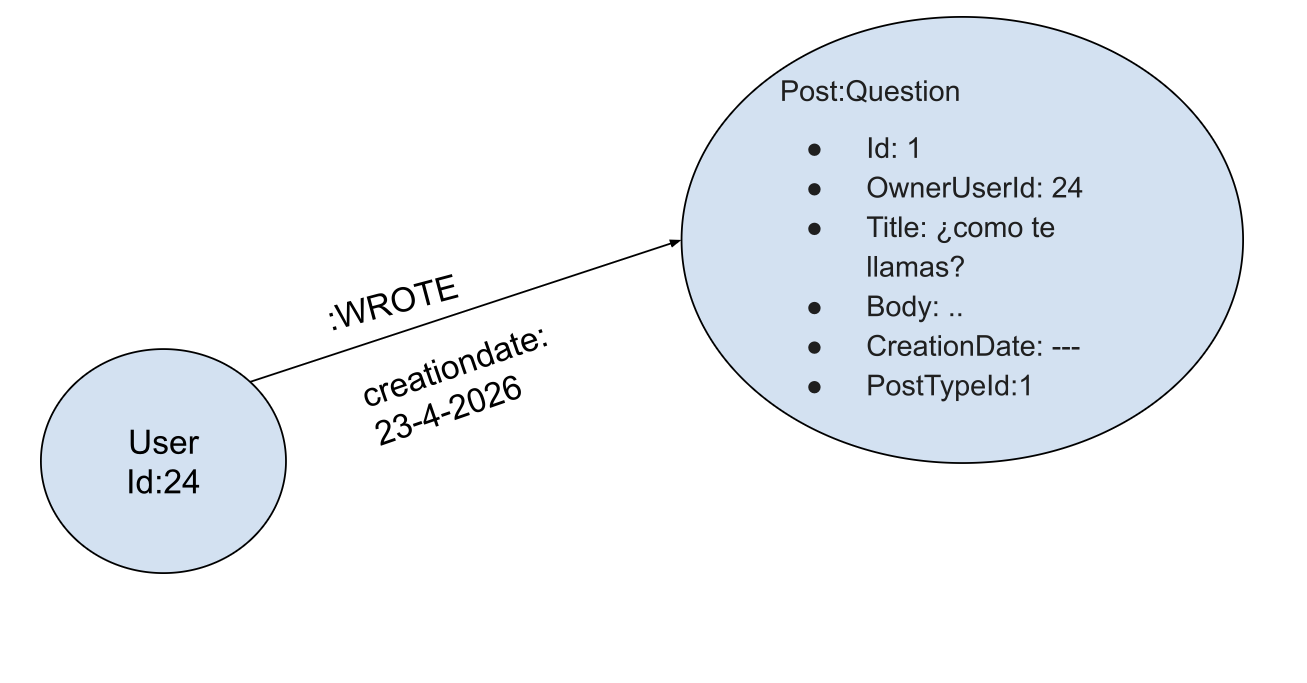

In [ ]:
with open_query('''
        match r=(u:User)-[:WROTE]->(p:Post) RETURN r LIMIT 20
''') as result:
  for record in result:
    pp(record)

Creamos un índice sobre el `Id` para acelerar las siguientes búsquedas:

In [ ]:
execute_query("CREATE INDEX IF NOT EXISTS FOR (n:Post) ON (n.Id);")

Añadimos una relación entre las preguntas y las respuestas:

In [ ]:
execute_query('''
    MATCH (a:Answer), (q:Post:Question {Id: a.ParentId})
    CREATE (a)-[:ANSWERS]->(q)
    ''').counters

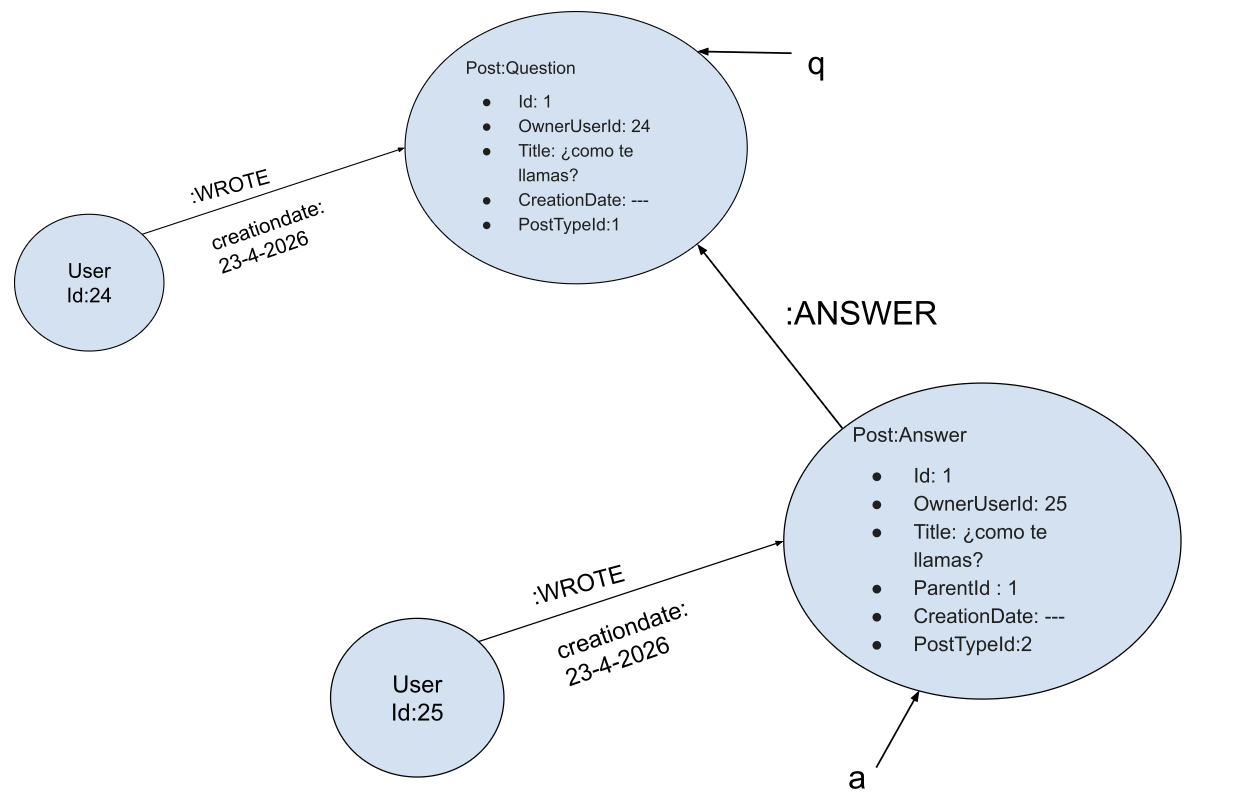

## Idempotencia de la carga: `CREATE` vs `MERGE`

Las celdas anteriores usaron `CREATE` para las relaciones `:WROTE` y `:ANSWERS`. Si se reejecutaran, duplicarían las relaciones existentes. `MERGE` es idempotente: primero busca el patrón y solo lo crea si no existe.

Para relaciones con propiedades, el patrón correcto combina `MERGE` del esqueleto (sin propiedades) con:
- `ON CREATE SET` — se ejecuta **solo al crear** el elemento.
- `ON MATCH SET` — se ejecuta **solo si ya existía** (por ejemplo para actualizar contadores).

Al reejecutar las versiones idempotentes, `relationships_created` será `0`, lo que confirma que no se han añadido duplicados.

In [ ]:
# Versión idempotente de ANSWERS (seguro re-ejecutar)
execute_query('''
    MATCH (a:Answer), (q:Post:Question {Id: a.ParentId})
    MERGE (a)-[:ANSWERS]->(q)
    ''').counters

In [ ]:
# Versión idempotente de WROTE (ON CREATE SET para propiedades)
execute_query('''
    MATCH (n:Post)
    WHERE n.OwnerUserId <> ""
        MERGE (u:User {Id: n.OwnerUserId})
        MERGE (u)-[r:WROTE]->(n)
        ON CREATE SET r.CreationDate = n.CreationDate
    ''').counters



Las construcciones `%cypher` retornan resultados de los que se puede obtener un `dataframe` de `pandas`:

In [ ]:
with open_query("MATCH q=(r)-[:ANSWERS]->(p) RETURN p.Id,r.Id;") as res:
  df = pd.DataFrame([r.values() for r in res], columns=res.keys())
  df['r.Id'] = pd.to_numeric(df['r.Id'],downcast='unsigned') #downcast para convertir tipos
  df['p.Id'] = pd.to_numeric(df['p.Id'],downcast='unsigned')

  df.plot(kind='scatter',x='p.Id',y='r.Id',figsize=(15,15))

La consulta de reciprocidad entre usuarios de Stackoverflow se puede resolver de manera muy fácil. En esta primera consulta se devuelve los nodos:

In [ ]:
with open_query('''// RQ4
    MATCH
    (u1:User)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u2:User),
    (u2)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u1)
    WHERE u1.Id < u2.Id
    RETURN DISTINCT u1,u2
    ''') as res:
  for r in res:
    print(r['u1'], r['u2'])

# MATCH ... : buscame un nodo con etiqueta usuario que tenga una flecha de wrote a lo que sea. Que de ese algo salga una flecha de relacion que tenga
# ANSWER a otro. Ahota me buscas el usuario2 que WROTE esa pregunta (flecha de relacion al reves). De u2 tiene que salir una flecha de WROTE hacia cualquier nodo, cuya respuesta fue
# escrita por u1.


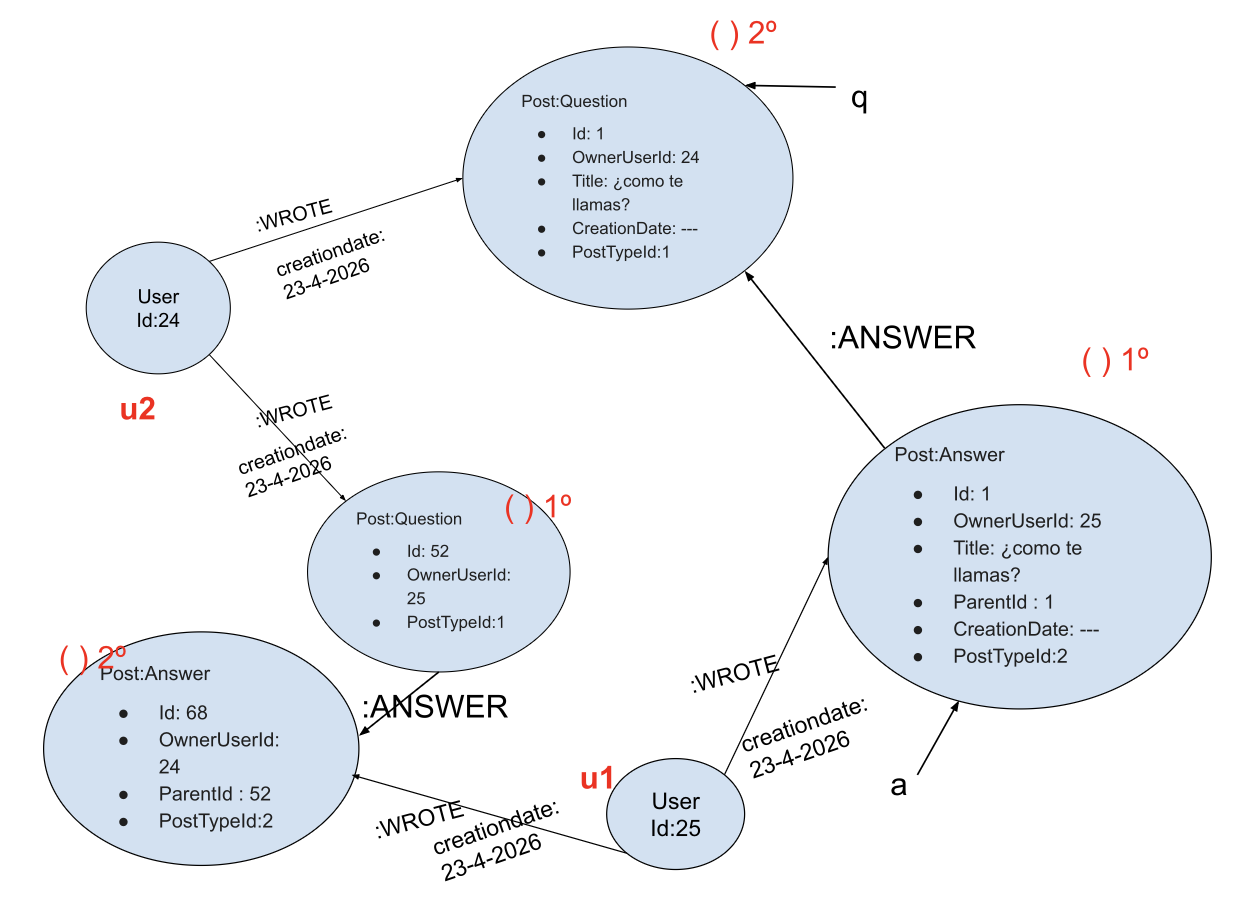

O bien retornar los `Id` de cada usuario:

In [ ]:
with open_query('''// RQ4
    MATCH
    (u1:User)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u2:User),
    (u2)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u1)
    WHERE u1.Id < u2.Id
    RETURN DISTINCT u1.Id,u2.Id
    ORDER BY u1.Id
    ''') as res:
  for r in res:
    print(r['u1.Id'], r['u2.Id'])

  # el where fuerza a que solo se encuentre una vez.

Y finalmente, la creación de relaciones `:RECIPROCATE` entre los usuarios. Se introduce también la construcción `WITH`.

`WITH` sirve para introducir "espacios de nombres". Permite importar nombres de filas anteriores, hacer alias con `AS` e introducir nuevos valores con funciones de Cypher. La siguiente consulta es la misma de arriba, RQ4, pero creando relaciones `:RECIPROCATE` entre cada dos usuarios que se ayudan recíprocamente.

In [ ]:
execute_query('''
    // RQ4 creando relaciones de reciprocidad
    MATCH
      (u1:User)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u2:User),
      (u2)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u1)
    WHERE u1.Id < u2.Id
    WITH u1 AS user1,u2 AS user2
      MERGE (user1)-[:RECIPROCATE]->(user2)
      MERGE (user2)-[:RECIPROCATE]->(user1)
    ''').counters

También se puede buscar el camino mínimo entre dos usuarios cualesquiera. Si existe un camino a través de alguna pregunta o respuesta, la encontrará. Un ejemplo donde hay una comunicación directa:

In [ ]:
with open_query("MATCH p=shortestPath( (u1:User {Id: 24})-[*]-(u2:User {Id:25}) ) RETURN p") as res:
  for r in res:
    print(r['p'])

Mientras que con otro usuario la cadena es más larga:

In [ ]:
with open_query("MATCH p=shortestPath( (u1:User {Id: 324})-[*]-(u2:User {Id:25}) ) RETURN p") as res:
  for r in res:
    print(r['p'])

Finalmente se pueden encontrar todos los caminos mínimos en donde se ve que tiene que existir al menos un par pregunta/respuesta entre los usuarios que son recíprocos:

In [ ]:
with open_query("MATCH p=allShortestPaths( (u1:User {Id: 24})-[*]-(u2:User {Id:25}) ) RETURN p") as res:
  for r in res:
    print(r['p'])
    # tengo 2 caminos que van del 24 al 25, o del 25 al 24

## Direccionalidad en Cypher

En Neo4j todas las relaciones tienen dirección, pero Cypher permite especificarla (`->`) o ignorarla (`-`) según convenga:

- **Dirigida** `(a)-[:REL]->(b)`: solo encuentra relaciones del tipo indicado que van de `a` a `b`.
- **No dirigida** `(a)-[:REL]-(b)`: encuentra la relación independientemente del sentido.

Usar la dirección correcta es crítico para evitar conteos dobles. En este modelo:
- `:WROTE` y `:ANSWERS` son semánticamente unidireccionales — siempre se consultan dirigidas.
- `:RECIPROCATE` se insertó explícitamente en **ambos sentidos** con dos `MERGE`. Una consulta no dirigida sobre ella contaría cada pareja dos veces.

In [ ]:
# Consulta dirigida: usuarios más prolíficos (WROTE apunta de usuario a post)
with open_query('''
    MATCH (u:User)-[:WROTE]->(p:Post)
    RETURN u.Id, count(p) AS posts
    ORDER BY posts DESC
    LIMIT 10
''') as res:
    for r in res:
        print(r)

In [ ]:
# RECIPROCATE se creó en ambos sentidos: la consulta dirigida cuenta la mitad que la no dirigida
with open_query('''
    MATCH (u1:User)-[:RECIPROCATE]->(u2:User) WHERE u1.Id < u2.Id
    RETURN count(*) AS pares_reciprocos_dirigida
''') as res:
    for r in res:
        print(r)

# Comparación: sin filtro de dirección cuenta cada pareja DOS veces
with open_query('''
    MATCH (u1:User)-[:RECIPROCATE]-(u2:User) WHERE u1.Id < u2.Id
    RETURN count(*) AS pares_reciprocos_sin_direccion
''') as res:
    for r in res:
        print(r)

In [ ]:
# Sin dirección: qué tipos de nodos rodean a un usuario (relaciones en cualquier sentido)
with open_query('''
    MATCH (u:User {Id: 24})-[r]-(vecino)
    RETURN type(r) AS relacion, labels(vecino) AS tipo, vecino.Id AS id
    ORDER BY type(r)
    LIMIT 20
''') as res:
    for r in res:
        print(r)

## Rendimiento y planificación: `EXPLAIN` y `PROFILE`

`EXPLAIN` genera el plan de ejecución **sin ejecutar** la consulta. Permite ver qué operadores usará Neo4j (`NodeByLabelScan`, `NodeIndexSeek`, etc.) y si se aprovechan los índices.

`PROFILE` **ejecuta** la consulta e incluye en cada nodo del plan el número real de filas procesadas (`rows`) y lecturas de base de datos (`db_hits`). Un `db_hits` alto en un paso indica un candidato a optimizar con un índice.

Ambos retornan el plan a través del `ResultSummary`: `summary.plan` para `EXPLAIN` y `summary.profile` para `PROFILE`.

In [ ]:
# EXPLAIN: plan sin ejecutar (no consume datos)
with driver.session() as session:
    summary = session.run('''
        EXPLAIN
        MATCH (u:User)-[:WROTE]->(p:Post)
        RETURN u.Id, count(p) AS posts
        ORDER BY posts DESC LIMIT 10
    ''').consume()
    pp(summary.plan)

In [ ]:
# PROFILE: ejecuta y anota el coste real de cada operador
with driver.session() as session:
    result = session.run('''
        PROFILE
        MATCH (u:User)-[:WROTE]->(p:Post)
        RETURN u.Id, count(p) AS posts
        ORDER BY posts DESC LIMIT 10
    ''')
    for r in result:
        print(r)
    summary = result.consume()
    pp(summary.profile)

## EJERCICIO: Construir los nodos `:Tag` para cada uno de los tags que aparecen en las preguntas. Construir las relaciones `post-[:TAGGED_BY]->tag` para cada tag y también `tag-[:TAGS]->post`

(**OJO**: Hay que crear un índice antes para `Tag.name`, si no el proceso es muy lento)


In [ ]:
# creamos el índice para Tag.name
execute_query(
    """
    CREATE INDEX tag_name_index IF NOT EXISTS
    FOR (t:Tag) ON (t.name)
    """
)

In [ ]:
print(execute_query(
    """
    MATCH (q:Question)
    WHITH q, split(q.Tags,'><') AS replacedtags
    UNWIND replacedtags AS tag
    WITH q, replace(replace(tag, '>', ''), '<', '') AS tag
    MERGE (t:Tag {name: tag})
    CREATE (q)-[:TAGGED_BY]->(t)
    CREATE (t)-[:TAGS]->(q)
    """
))

# solo busco los nodos que tengan la etiqueta question, pues son los únicos posts que tienen tags.
# MERGE (t:Tag {name: tag}) : buscamos nodos con la etiqueta tag

Para ello, buscar en la ayuda las construcciones `WITH` y `UNWIND` y las funciones `replace()` y `split()` de Cypher. La siguiente consulta debe retornar `26135` resultados:

In [ ]:
with open_query('''
    MATCH p=(t:Tag)-[:TAGS]->(:Question) WHERE t.name =~ "^java$|^c\\\\+\\\\+$" RETURN count(p);
''') as res:
  for r in res:
    print(r)

La siguiente consulta muestra los usuarios que preguntan por cada Tag:

In [ ]:
from itertools import islice

with open_query("MATCH (t:Tag)-->(:Question)<--(u:User) RETURN t.name,collect(distinct u.Id) ORDER BY t.name;") as res:
  for r in islice(res, 20):
    print(r)

El mismo `MATCH` se puede usar para encontrar qué conjunto de tags ha usado cada usuario cambiando lo que retornamos:

In [ ]:
with open_query("MATCH (t:Tag)-->(:Question)<--(u:User) RETURN u.Id, collect(distinct t.name) ORDER BY toInteger(u.Id) LIMIT 100;") as res:
  for r in islice(res, 20):
    print(r)

## EJERCICIO: Relacionar cada usuario con los tags de sus preguntas a través de la relación `:INTERESTED_IN`.

In [ ]:
execute_query(
    """
    MATCH (u:User)-[:POSTED]->(q:question)-[:TAGGED_BY]->(t:Tag)
    MERGE (u)-[:INTERESTED_IN]->(t)
    """
)

Con la solución correcta, la siguiente consulta debe dar el resultado de 10166.

In [ ]:
query='''MATCH (u:User)-[:INTERESTED_IN]->(t:Tag {name: 'java'})
 RETURN count(u)
 '''
with open_query(query) as res:
  for r in res:
    print(r)

## Consultas relacionadas con el tiempo

El campo `CreationDate` de los nodos `:Post` permite explorar la evolución de la actividad en el tiempo. Está almacenado como una fecha de Neo4j, que el driver de Python transforma en un `datetime` de Python. Se pueden usar funciones de Cypher para extraer el año, mes o día:

In [ ]:
# Las 5 preguntas más antiguas del conjunto de datos
with open_query('''
    MATCH (q:Question)
    WHERE q.CreationDate IS NOT NULL
    RETURN q.Id, q.CreationDate
    ORDER BY q.CreationDate ASC
    LIMIT 5
''') as res:
    for r in res:
        print(r)

In [ ]:
# Número de preguntas por año de creación
with open_query('''
    MATCH (q:Question)
    WHERE q.CreationDate IS NOT NULL
    RETURN q.CreationDate.year AS año, count(q) AS preguntas
    ORDER BY año
''') as res:
    for r in res:
        print(r)

## Calidad de datos

Los grafos cargados desde fuentes externas pueden contener inconsistencias: nodos sin propiedades clave, relaciones huérfanas o referencias que apuntan a nodos inexistentes. Detectarlas antes de lanzar análisis evita resultados silenciosamente incorrectos.

Las siguientes consultas comprueban:
- Posts sin propietario (`OwnerUserId` vacío).
- Respuestas sin ninguna relación `:ANSWERS` en el grafo.
- Preguntas cuya respuesta aceptada (`AcceptedAnswerId`) no existe como nodo `:Answer`.

In [ ]:
# Preguntas sin ninguna respuesta registrada como relación en el grafo
with open_query('''
    MATCH (a:Answer)
    WHERE NOT ()<-[:ANSWERS]-(a)
    RETURN count(a) AS respuestas_sin_pregunta_en_grafo
''') as res:
    for r in res:
        print(r)

# Posts sin propietario (OwnerUserId vacío)
with open_query('''
    MATCH (p:Post)
    WHERE p.OwnerUserId = "" OR p.OwnerUserId IS NULL
    RETURN labels(p) AS tipo, count(p) AS sin_propietario
    ORDER BY tipo
''') as res:
    for r in res:
        print(r)

**OJO**: En el siguiente ejemplo se utiliza la nomenclatura `nodo:Post:Answer`, ya que Answer es una etiqueta que hereda de `Post`. Esto se hace así porque el único índice que se ha definido es de `Post.Id`. Aún así como todos los `Answer` son también `Posts`, el índice se puede usar para acelerar la consulta. Si se hubiera definido un índice específico para `Answer.Id`, entonces habría que usar `nodo:Answer` para aprovecharlo.

Este es un ejemplo donde la diferencia entre tener un índice o no es abismal. Sin índice, la consulta tarda **más de 10 minutos**, mientras que así dura **menos de un segundo**.

In [ ]:
# Integridad referencial: preguntas cuya respuesta aceptada no existe como nodo en el grafo
with open_query('''
    MATCH (q:Question)
    WHERE q.AcceptedAnswerId IS NOT NULL
      AND NOT EXISTS { MATCH (a:Post:Answer {Id: q.AcceptedAnswerId}) }
    RETURN count(q) AS aceptadas_sin_nodo_respuesta
''') as res:
    for r in res:
        print(r)

## EJERCICIO: Cargar el Parquet de Users y añadir las propiedades faltantes a los usuarios (hasta ahora cada nodo `:User` sólo tiene la propiedad `Id`. Hay que cargar el resto a partir del Parquet).

In [ ]:
with open_query("""
    MATCH (u:User)-[:INTERESTED_IN]->(t:Tag)
    RETURN t.name, collect(u.Id) AS Users
    ORDER BY t.name
    """) as res:
    for r in islice(res, 20):
        print(r)

Si la importación fue correcta, se puede acceder a la media de puntuación de los usuarios, cuyo valor debe ser: "`avg(rep)=21.546268796844668 max(rep)=109420 min(rep)=1`".

In [ ]:
query='''MATCH (u:User)
 WITH u.Reputation AS rep
 RETURN avg(rep), max(rep), min(rep)
 '''
with open_query(query) as res:
  for r in res:
    print(r)